In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
data=yf.download(tickers="AAPL",start="2024-01-01",end="2025-01-01")

/tmp/ipykernel_2625/1935332915.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers="AAPL",start="2024-01-01",end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
df=pd.DataFrame(data)

In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700
2024-01-03,182.355591,183.968836,181.544015,182.325900,58414500
2024-01-04,180.039673,181.207533,179.020264,180.277196,71983600
2024-01-05,179.317169,180.880926,178.317559,180.118854,62379700
2024-01-08,183.652161,183.691758,179.633906,180.217836,59144500
...,...,...,...,...,...
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100


In [5]:
df["Next_Close"]=df["Close"].shift(-1)

In [13]:
df

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700,182.355591
2024-01-03,182.355591,183.968836,181.544015,182.325900,58414500,180.039673
2024-01-04,180.039673,181.207533,179.020264,180.277196,71983600,179.317169
2024-01-05,179.317169,180.880926,178.317559,180.118854,62379700,183.652161
2024-01-08,183.652161,183.691758,179.633906,180.217836,59144500,183.236450
...,...,...,...,...,...,...
2024-12-23,253.883133,254.261058,252.073014,253.385849,40858800,256.797241
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700,257.612732


In [14]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0
Next_Close,,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2024-01-02 to 2024-12-30
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
 5   (Next_Close, )  251 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 13.7 KB


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dropna(inplace=True)

In [18]:
X=df.drop(["Next_Close","Close"],axis=1)
Y=df["Next_Close"]

In [20]:
Y

,Next_Close
Date,
2024-01-02,182.355591
2024-01-03,180.039673
2024-01-04,179.317169
2024-01-05,183.652161
2024-01-08,183.236450
...,...
2024-12-23,256.797241
2024-12-24,257.612732
2024-12-26,254.201385


In [ ]:
n_rows=len(df)

In [27]:
split_index=int(n_rows*80/100)

In [29]:
X_train=X.iloc[:split_index]
Y_train=Y.iloc[:split_index]

X_test=X.iloc[split_index:]
Y_test=Y.iloc[split_index:]

In [30]:
X_train

Price,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-02,186.502538,181.999316,185.225793,82488700
2024-01-03,183.968836,181.544015,182.325900,58414500
2024-01-04,181.207533,179.020264,180.277196,71983600
2024-01-05,180.880926,178.317559,180.118854,62379700
2024-01-08,183.691758,179.633906,180.217836,59144500
...,...,...,...,...
2024-10-10,228.002262,225.687466,226.293486,28183500
2024-10-11,227.912849,225.856351,227.803566,31759200


In [31]:
Y_train

,Next_Close
Date,
2024-01-02,182.355591
2024-01-03,180.039673
2024-01-04,179.317169
2024-01-05,183.652161
2024-01-08,183.236450
...,...
2024-10-10,226.064987
2024-10-11,229.790512
2024-10-14,232.323883


In [32]:
lr=LinearRegression()

In [33]:
lr.fit(X_train,Y_train)

LinearRegression()

In [34]:
y_pred=lr.predict(X_test)

In [35]:
print(f"R2 score is: {r2_score(Y_test,y_pred)}")

R2 score is: 0.9476615370861462


In [36]:
print(f"Mean square error is: {mean_squared_error(Y_test,y_pred)}")
print(f"Mean absolute error is: {mean_absolute_error(Y_test,y_pred)}")

Mean square error is: 6.285827420803639
Mean absolute error is: 2.074995842341066


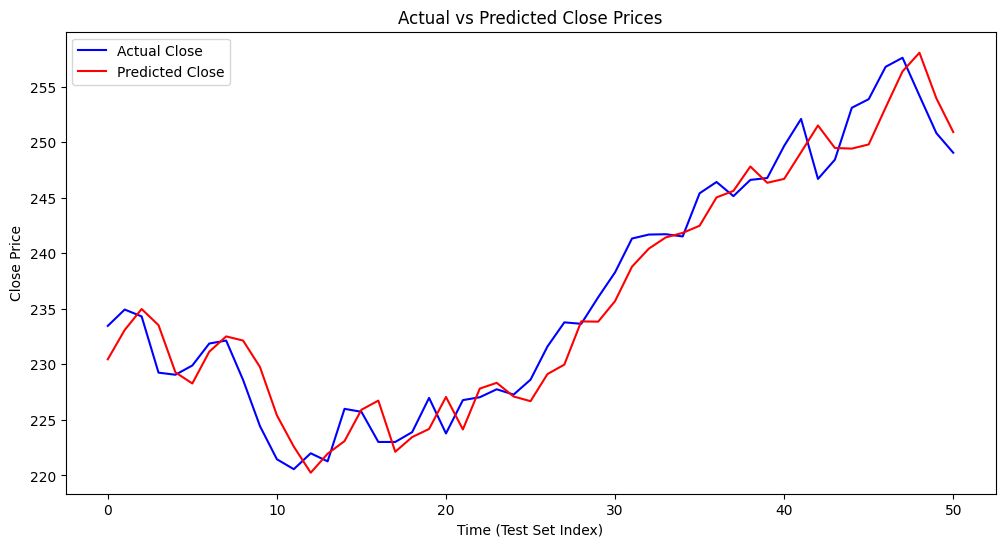

In [47]:
plt.figure(figsize=(12,6))

plt.plot(Y_test.values,label='Actual Close',color="blue")
plt.plot(y_pred,label="Predicted Close",color="red")

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Time (Test Set Index)')
plt.ylabel("Close Price")
plt.legend()